In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU disponible: True


## Organizar Dataset

In [ ]:
SOURCE_DIR = '/content/drive/MyDrive/dogs-vs-cats/train'  # carpeta con las 25.000 imágenes
DATASET_DIR = '/content/dataset'                          # destino organizado por carpetas
TRAIN_RATIO = 0.8               # 80% entrenamiento, 20% test
SEED = 42
# ============================================================

def organizar_dataset(source_dir, dest_dir, train_ratio=0.8, seed=42):
    """Reorganiza las imágenes de la carpeta plana original en train/test con subcarpetas por clase."""
    random.seed(seed)

    # Separar archivos por clase
    all_files = os.listdir(source_dir)
    cats = [f for f in all_files if f.startswith('cat')]
    dogs = [f for f in all_files if f.startswith('dog')]

    print(f'Total imágenes - Gatos: {len(cats)}, Perros: {len(dogs)}')

    # Mezclar aleatoriamente
    random.shuffle(cats)
    random.shuffle(dogs)

    # Split train/test
    splits = {
        'train': {'cats': cats[:int(len(cats)*train_ratio)],
                  'dogs': dogs[:int(len(dogs)*train_ratio)]},
        'test':  {'cats': cats[int(len(cats)*train_ratio):],
                  'dogs': dogs[int(len(dogs)*train_ratio):]}
    }

    for split, classes in splits.items():
        for clase, archivos in classes.items():
            dest = os.path.join(dest_dir, split, clase)
            os.makedirs(dest, exist_ok=True)
            for archivo in archivos:
                shutil.copy(os.path.join(source_dir, archivo), os.path.join(dest, archivo))
        print(f'{split}: cats={len(splits[split]["cats"])}, dogs={len(splits[split]["dogs"])}')

    print('✅ Dataset organizado correctamente.')

# Ejecutar solo si el dataset aún no está organizado
if not os.path.exists(DATASET_DIR):
    organizar_dataset(SOURCE_DIR, DATASET_DIR, TRAIN_RATIO, SEED)
else:
    print('El directorio ya existe, se omite la reorganización.')

Total imágenes - Gatos: 12500, Perros: 12500
train: cats=10000, dogs=10000
test: cats=2500, dogs=2500
✅ Dataset organizado correctamente.


## Visualizar imágenes de entrada

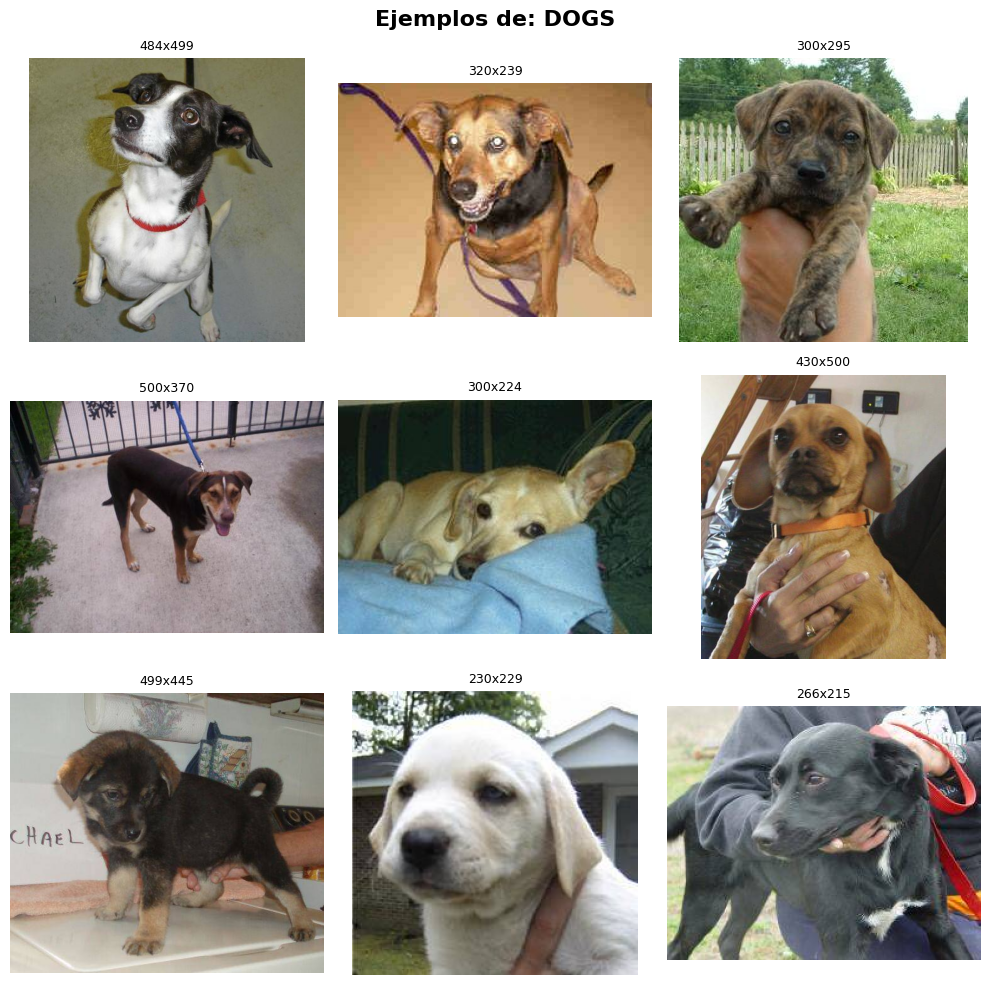

Nota: Las imágenes tienen tamaños variados. Se redimensionarán a 224x224 para el modelo.


In [ ]:
def mostrar_imagenes(clase, n=9, dataset_dir=DATASET_DIR):
    """Muestra una cuadrícula de 3x3 con imágenes de la clase indicada."""
    carpeta = os.path.join(dataset_dir, 'train', clase)
    archivos = random.sample(os.listdir(carpeta), n)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(f'Ejemplos de: {clase.upper()}', fontsize=16, fontweight='bold')

    for ax, archivo in zip(axes.flatten(), archivos):
        img = Image.open(os.path.join(carpeta, archivo))
        ax.imshow(img)
        ax.set_title(f'{img.size[0]}x{img.size[1]}', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Nota: Las imágenes tienen tamaños variados. Se redimensionarán a 224x224 para el modelo.')

mostrar_imagenes('dogs')

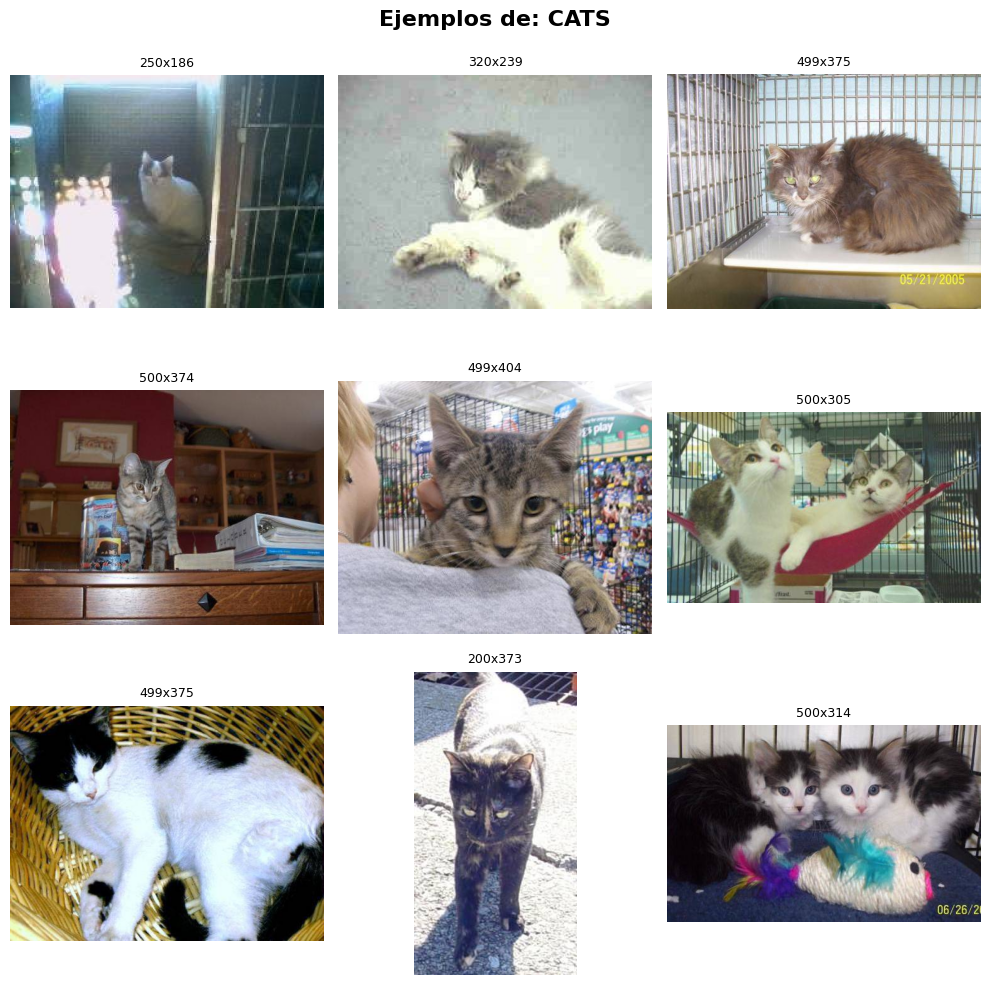

Nota: Las imágenes tienen tamaños variados. Se redimensionarán a 224x224 para el modelo.


In [ ]:
mostrar_imagenes('cats')

## Generadores de datos con ImageDataGenerator

Se utliza `ImageDataGenerator` + `flow_from_directory()`

In [ ]:
IMG_SIZE = (224, 224)   # VGG16 usa 224x224
BATCH_SIZE = 32

# Generador de entrenamiento CON data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalizar píxeles a [0, 1]
    horizontal_flip=True,     # volteo horizontal aleatorio
    rotation_range=15,        # rotación aleatoria ±15°
    zoom_range=0.1,           # zoom aleatorio ±10%
    width_shift_range=0.1,    # desplazamiento horizontal
    height_shift_range=0.1    # desplazamiento vertical
)

# Generador de test SIN augmentation (solo normalización)
test_datagen = ImageDataGenerator(rescale=1./255)

# Crear flujos de datos desde las carpetas
trdata = train_datagen.flow_from_directory(
    directory=os.path.join(DATASET_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # softmax en la salida → necesita one-hot
    seed=SEED
)

tsdata = test_datagen.flow_from_directory(
    directory=os.path.join(DATASET_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False               # importante: no mezclar para evaluar correctamente
)

print(f'Clases detectadas: {trdata.class_indices}')
print(f'Batches de entrenamiento: {len(trdata)}')
print(f'Batches de test: {len(tsdata)}')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Clases detectadas: {'cats': 0, 'dogs': 1}
Batches de entrenamiento: 625
Batches de test: 157


## Construir la CNN (arquitectura VGG16-like)

In [ ]:
model = Sequential([
    # Bloque 1: 2 convoluciones × 64 filtros
    Conv2D(input_shape=(224, 224, 3), filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    # Bloque 2: 2 convoluciones × 128 filtros
    Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    # Bloque 3: 3 convoluciones × 256 filtros
    Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    # Bloque 4: 3 convoluciones × 512 filtros
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    # Bloque 5: 3 convoluciones × 512 filtros
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),

    # Clasificador fully connected
    Flatten(),
    Dense(units=4096, activation='relu'),
    Dropout(0.5),               # regularización: apaga 50% de neuronas en cada paso
    Dense(units=4096, activation='relu'),
    Dropout(0.5),
    Dense(units=2, activation='softmax')   # 2 clases: cat / dog
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 134,268,738 (512.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Modelo compilado ✅')

Modelo compilado ✅


## Entrenar con callbacks (EarlyStopping + ModelCheckpoint)

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/models/best_cats_dogs_model.keras'
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

# Guarda automáticamente el mejor modelo según val_accuracy
checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Detiene el entrenamiento si val_loss no mejora en 5 epochs consecutivas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print('Callbacks configurados ✅')

Callbacks configurados ✅


In [ ]:
EPOCHS = 50  # EarlyStopping detendrá el entrenamiento antes si no hay mejora

history = model.fit(
    trdata,
    epochs=EPOCHS,
    validation_data=tsdata,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.5045 - loss: 0.7271
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /content/drive/MyDrive/models/best_cats_dogs_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/models/best_cats_dogs_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 503s 735ms/step - accuracy: 0.5070 - loss: 0.6990 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.5046 - loss: 0.6930
Epoch 2: val_accuracy did not improve from 0.50000
625/625 ━━━━━━━━━━━━━━━━━━━━ 435s 695ms/step - accuracy: 0.4977 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.5005 - loss: 0.6933
Epoch 3: val_accuracy did not improve from 0.50000
625/625 ━━━━━━━━━━━━━━━━━━━━ 399s 638ms/step - accuracy: 0.4983 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step

In [ ]:
x_batch, y_batch = next(iter(trdata))
print(f'Etiquetas primeras 5: {y_batch[:5]}')
print(f'Min/Max imágenes: {x_batch.min():.2f} / {x_batch.max():.2f}')

Etiquetas primeras 5: [[0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
Min/Max imágenes: 0.00 / 1.00


## Evaluación del mejor modelo

In [ ]:
# Cargar el mejor modelo guardado por ModelCheckpoint
best_model = load_model(MODEL_PATH)
print(f'Mejor modelo cargado desde: {MODEL_PATH}')

# Evaluar sobre el conjunto de test
loss, accuracy = best_model.evaluate(tsdata, verbose=1)
print(f'\n📊 Resultados en test:')
print(f'   Loss:     {loss:.4f}')
print(f'   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

Mejor modelo cargado desde: /content/drive/MyDrive/models/best_cats_dogs_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 198ms/step - accuracy: 0.5000 - loss: 0.6937

📊 Resultados en test:
   Loss:     0.6937
   Accuracy: 0.5000 (50.00%)


157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step

📋 Reporte de clasificación:
              precision    recall  f1-score   support

        cats       0.50      1.00      0.67      2500
        dogs       0.00      0.00      0.00      2500

    accuracy                           0.50      5000
   macro avg       0.25      0.50      0.33      5000
weighted avg       0.25      0.50      0.33      5000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


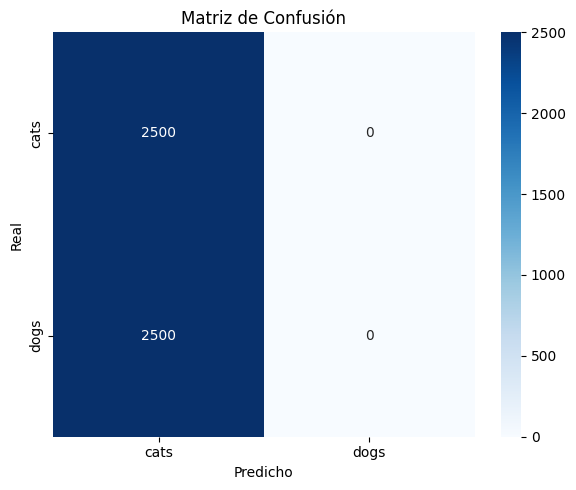

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predicciones
tsdata.reset()
y_pred_probs = best_model.predict(tsdata, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = tsdata.classes

class_names = list(tsdata.class_indices.keys())

# Reporte de clasificación
print('\n📋 Reporte de clasificación:')
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

## Guardar el modelo

El mejor modelo ya fue guardado automáticamente por `ModelCheckpoint` en `models/`. Aquí lo guardamos también con nombre final.

In [ ]:
# Guardar modelo final en Google Drive (persistente)
best_model.save('/content/drive/MyDrive/models/cats_dogs_final_model.keras')
print('Modelo guardado en Google Drive ✅')

Modelo guardado en Google Drive ✅


In [ ]:
# Predicción sobre una imagen individual
from tensorflow.keras.preprocessing import image as keras_image

def predecir_imagen(ruta_imagen, model, class_names):
    """Carga una imagen y predice si es perro o gato."""
    img = keras_image.load_img(ruta_imagen, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    clase_idx = np.argmax(pred)
    confianza = pred[0][clase_idx]

    plt.imshow(img)
    plt.title(f'Predicción: {class_names[clase_idx].upper()} ({confianza*100:.1f}% confianza)')
    plt.axis('off')
    plt.show()

predecir_imagen('/content/dataset/test/dogs/dog.1.jpg', best_model, class_names)